In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("uncleaned_colorectal_data.csv")


df.head()


,Participant_ID,Age,Gender,BMI,Lifestyle,Ethnicity,Family_History_CRC,Pre-existing Conditions,Carbohydrates (g),Proteins (g),Fats (g),Vitamin A (IU),Vitamin C (mg),Iron (mg),CRC_Risk
0,1001,63.0,Female,21.6,Sedentary,Hispanic,Yes,Diabetes,245,98,41,4176,97,15.3,0
1,1002,76.0,Male,NaN,Smoker,Hispanic,No,Obesity,398,56,61,3400,38,9.5,1
2,1003,53.0,Female,24.3,Moderate Exercise,Asian,No,NaN,375,79,59,5104,51,14.4,0
3,1004,39.0,Male,19.5,Sedentary,Asian,Yes,NaN,325,98,64,6050,47,NaN,0
4,1005,67.0,Male,34.5,Moderate Exercise,Asian,No,Obesity,169,65,54,5233,105,12.0,0


In [2]:

df.shape

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Participant_ID           1005 non-null   int64  
 1   Age                      905 non-null    float64
 2   Gender                   1005 non-null   object 
 3   BMI                      904 non-null    float64
 4   Lifestyle                1005 non-null   object 
 5   Ethnicity                1005 non-null   object 
 6   Family_History_CRC       1005 non-null   object 
 7   Pre-existing Conditions  765 non-null    object 
 8   Carbohydrates (g)        1005 non-null   int64  
 9   Proteins (g)             1005 non-null   int64  
 10  Fats (g)                 1005 non-null   int64  
 11  Vitamin A (IU)           1005 non-null   int64  
 12  Vitamin C (mg)           1005 non-null   int64  
 13  Iron (mg)                904 non-null    float64
 14  CRC_Risk                

## Target Variable Setup

This cell converts the `CRC_Risk` column into a categorical variable, as it represents class labels (low vs high cancer risk).

In [3]:
df["CRC_Risk"] = df["CRC_Risk"].astype("category")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Participant_ID           1005 non-null   int64   
 1   Age                      905 non-null    float64 
 2   Gender                   1005 non-null   object  
 3   BMI                      904 non-null    float64 
 4   Lifestyle                1005 non-null   object  
 5   Ethnicity                1005 non-null   object  
 6   Family_History_CRC       1005 non-null   object  
 7   Pre-existing Conditions  765 non-null    object  
 8   Carbohydrates (g)        1005 non-null   int64   
 9   Proteins (g)             1005 non-null   int64   
 10  Fats (g)                 1005 non-null   int64   
 11  Vitamin A (IU)           1005 non-null   int64   
 12  Vitamin C (mg)           1005 non-null   int64   
 13  Iron (mg)                904 non-null    float64 
 14  CRC_Risk

In [4]:
df.drop(columns=["Participant_ID"], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Age                      905 non-null    float64 
 1   Gender                   1005 non-null   object  
 2   BMI                      904 non-null    float64 
 3   Lifestyle                1005 non-null   object  
 4   Ethnicity                1005 non-null   object  
 5   Family_History_CRC       1005 non-null   object  
 6   Pre-existing Conditions  765 non-null    object  
 7   Carbohydrates (g)        1005 non-null   int64   
 8   Proteins (g)             1005 non-null   int64   
 9   Fats (g)                 1005 non-null   int64   
 10  Vitamin A (IU)           1005 non-null   int64   
 11  Vitamin C (mg)           1005 non-null   int64   
 12  Iron (mg)                904 non-null    float64 
 13  CRC_Risk                 1005 non-null   category
dtypes: categ

In [5]:
df.isnull().sum()


Age                        100
Gender                       0
BMI                        101
Lifestyle                    0
Ethnicity                    0
Family_History_CRC           0
Pre-existing Conditions    240
Carbohydrates (g)            0
Proteins (g)                 0
Fats (g)                     0
Vitamin A (IU)               0
Vitamin C (mg)               0
Iron (mg)                  101
CRC_Risk                     0
dtype: int64

## Handling Missing Numerical Values

This cell fills missing values in numerical features (`Age`, `BMI`, and `Iron (mg)`) using the median.  
Median imputation is used because it is robust to outliers and preserves the overall distribution of the data.


In [6]:
from sklearn.impute import SimpleImputer

num_cols = ["Age", "BMI", "Iron (mg)"]

num_imputer = SimpleImputer(strategy="median")
df[num_cols] = num_imputer.fit_transform(df[num_cols])


## Handling Missing Categorical Values

This cell fills missing values in the `Pre-existing Conditions` categorical feature using the most frequent value.  
Mode imputation is appropriate for categorical data and preserves the most common category in the dataset.


In [7]:
cat_cols = ["Pre-existing Conditions"]

cat_imputer = SimpleImputer(strategy="most_frequent")
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])


In [8]:
df.isnull().sum()


Age                        0
Gender                     0
BMI                        0
Lifestyle                  0
Ethnicity                  0
Family_History_CRC         0
Pre-existing Conditions    0
Carbohydrates (g)          0
Proteins (g)               0
Fats (g)                   0
Vitamin A (IU)             0
Vitamin C (mg)             0
Iron (mg)                  0
CRC_Risk                   0
dtype: int64

## Feature–Target Separation

This cell separates the dataset into input features (`X`) and the target variable (`y`).  
This step prepares the data for machine learning models by clearly defining what is used for prediction and what is being predicted.


In [9]:
X = df.drop(columns=["CRC_Risk"])
y = df["CRC_Risk"]


In [10]:


X["Ethnicity"] = (
    X["Ethnicity"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "hispanc": "hispanic"
    })
)

# Identify categorical & numerical columns
cat_cols = X.select_dtypes(include=["object"]).columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns


In [11]:
cat_cols = X.select_dtypes(include=["object"]).columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns

cat_cols, num_cols


(Index(['Gender', 'Lifestyle', 'Ethnicity', 'Family_History_CRC',
        'Pre-existing Conditions'],
       dtype='object'),
 Index(['Age', 'BMI', 'Carbohydrates (g)', 'Proteins (g)', 'Fats (g)',
        'Vitamin A (IU)', 'Vitamin C (mg)', 'Iron (mg)'],
       dtype='object'))

## One-Hot Encoding of Categorical Features

This cell converts categorical variables into numerical format using one-hot encoding.  
makes data suitable for machine learning models.


In [12]:
for col in cat_cols:
    X[col] = (
        X[col]
        .astype(str)
        .str.strip()
        .str.lower()
    )


In [13]:
for col in cat_cols:
    X[col] = (
        X[col]
        .str.strip()
        .str.lower()
    )


In [14]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop="first", sparse_output=False)

X_cat_encoded = encoder.fit_transform(X[cat_cols])

X_cat_encoded = pd.DataFrame(
    X_cat_encoded,
    columns=encoder.get_feature_names_out(cat_cols),
    index=X.index
)


In [15]:
X_cat_encoded.head(10)


,Gender_male,Lifestyle_moderate exercise,Lifestyle_sedentary,Lifestyle_smoker,Ethnicity_afro-american,Ethnicity_asian,Ethnicity_caucasian,Ethnicity_hispanic,Family_History_CRC_yes,Pre-existing Conditions_hypertension,Pre-existing Conditions_obesity
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
4,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
5,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
8,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0


In [17]:
X_final = pd.concat([X[num_cols], X_cat_encoded], axis=1)


In [18]:
X_final.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Age                                   1005 non-null   float64
 1   BMI                                   1005 non-null   float64
 2   Carbohydrates (g)                     1005 non-null   int64  
 3   Proteins (g)                          1005 non-null   int64  
 4   Fats (g)                              1005 non-null   int64  
 5   Vitamin A (IU)                        1005 non-null   int64  
 6   Vitamin C (mg)                        1005 non-null   int64  
 7   Iron (mg)                             1005 non-null   float64
 8   Gender_male                           1005 non-null   float64
 9   Lifestyle_moderate exercise           1005 non-null   float64
 10  Lifestyle_sedentary                   1005 non-null   float64
 11  Lifestyle_smoker 

In [19]:
# --- FIX DUPLICATE ONE-HOT COLUMNS CLEANLY ---

from sklearn.preprocessing import OneHotEncoder

# 1) Normalize categorical text (case + spaces)
for col in cat_cols:
    X[col] = (
        X[col]
        .astype(str)
        .str.strip()
        .str.lower()
    )

# 2) Re-run One-Hot Encoding from scratch
encoder = OneHotEncoder(drop="first", sparse_output=False)

X_cat_encoded = encoder.fit_transform(X[cat_cols])

X_cat_encoded = pd.DataFrame(
    X_cat_encoded,
    columns=encoder.get_feature_names_out(cat_cols),
    index=X.index
)

# 3) Rebuild final feature matrix
X_final = pd.concat([X[num_cols], X_cat_encoded], axis=1)

# 4) Final sanity check
X_final.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Age                                   1005 non-null   float64
 1   BMI                                   1005 non-null   float64
 2   Carbohydrates (g)                     1005 non-null   int64  
 3   Proteins (g)                          1005 non-null   int64  
 4   Fats (g)                              1005 non-null   int64  
 5   Vitamin A (IU)                        1005 non-null   int64  
 6   Vitamin C (mg)                        1005 non-null   int64  
 7   Iron (mg)                             1005 non-null   float64
 8   Gender_male                           1005 non-null   float64
 9   Lifestyle_moderate exercise           1005 non-null   float64
 10  Lifestyle_sedentary                   1005 non-null   float64
 11  Lifestyle_smoker 

StandardScaler.
This prevents features with larger numeric ranges from dominating the model and improves training stability for algorithms such as logistic regression.

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_final[num_cols] = scaler.fit_transform(X_final[num_cols])

X_final.describe().T[["mean", "std"]]


,mean,std
Age,-1.961946e-16,1.000498
BMI,7.229154e-16,1.000498
Carbohydrates (g),3.764816e-16,1.000498
Proteins (g),2.828031e-17,1.000498
Fats (g),8.572468e-17,1.000498
Vitamin A (IU),-7.556145e-17,1.000498
Vitamin C (mg),-1.060512e-17,1.000498
Iron (mg),1.095862e-16,1.000498
Gender_male,5.522388e-01,0.497511
Lifestyle_moderate exercise,2.616915e-01,0.439774


In [21]:
y.value_counts()


CRC_Risk
0    849
1    156
Name: count, dtype: int64

CRC Risk Class Distribution

This bar chart shows the number of patients with and without colorectal cancer risk, highlighting the class imbalance in the dataset.

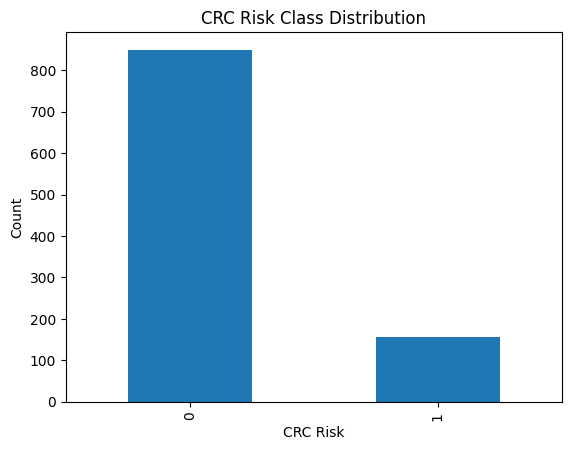

In [22]:
import matplotlib.pyplot as plt

y.value_counts().plot(kind="bar")
plt.title("CRC Risk Class Distribution")
plt.xlabel("CRC Risk")
plt.ylabel("Count")
plt.show()


Age vs CRC Risk

This boxplot compares the age distribution of patients with and without colorectal cancer risk to assess whether age differs between the two groups.

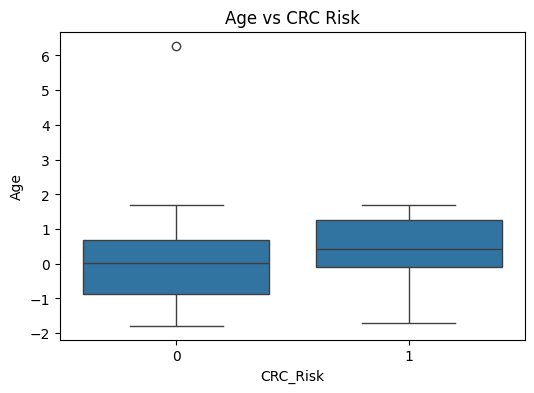

In [23]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.boxplot(x=y, y=X_final["Age"])
plt.title("Age vs CRC Risk")
plt.show()


Correlation Heatmap of Features and CRC Risk

This heatmap visualizes the correlations between all input features and colorectal cancer risk, helping identify which variables are most strongly associated with increased risk.

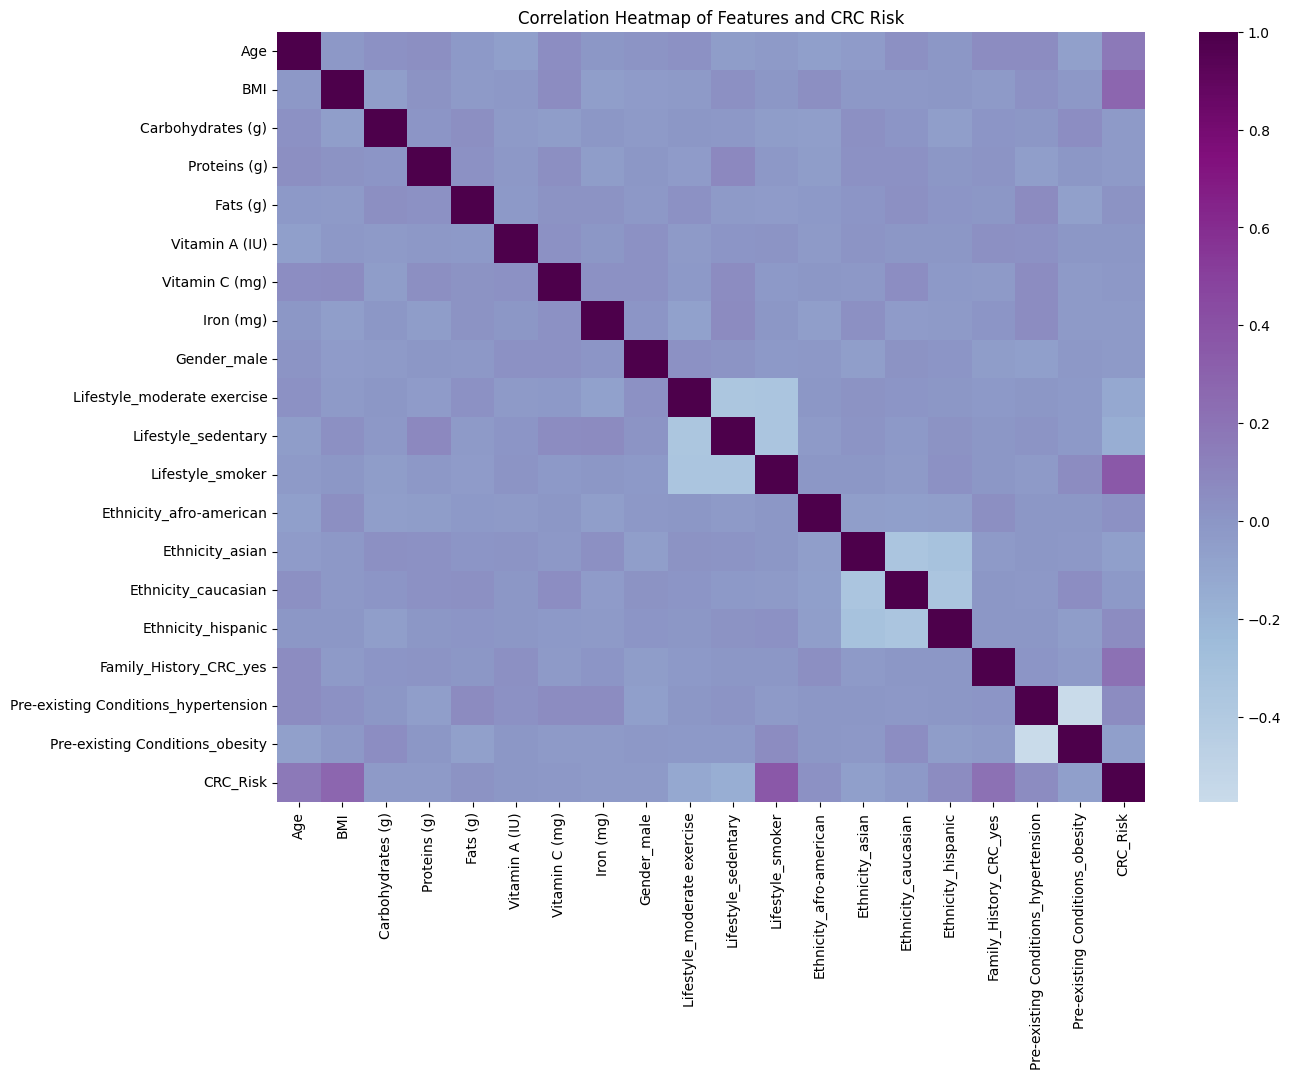

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = pd.concat([X_final, y], axis=1).corr()

plt.figure(figsize=(14,10))
sns.heatmap(
    corr,
    cmap="BuPu",
    center=0,
    annot=False
)
plt.title("Correlation Heatmap of Features and CRC Risk")
plt.show()


In [27]:
X_final.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Age                                   1005 non-null   float64
 1   BMI                                   1005 non-null   float64
 2   Carbohydrates (g)                     1005 non-null   float64
 3   Proteins (g)                          1005 non-null   float64
 4   Fats (g)                              1005 non-null   float64
 5   Vitamin A (IU)                        1005 non-null   float64
 6   Vitamin C (mg)                        1005 non-null   float64
 7   Iron (mg)                             1005 non-null   float64
 8   Gender_male                           1005 non-null   float64
 9   Lifestyle_moderate exercise           1005 non-null   float64
 10  Lifestyle_sedentary                   1005 non-null   float64
 11  Lifestyle_smoker 

This step computes and ranks the correlation between each feature and colorectal cancer risk to identify the most influential predictors.

In [28]:
corr = pd.concat([X_final, y], axis=1).corr()

corr_target = corr["CRC_Risk"].drop("CRC_Risk")

corr_sorted = corr_target.reindex(
    corr_target.abs().sort_values().index
)


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))


Logistic Regression
              precision    recall  f1-score   support

           0       0.93      0.83      0.88       170
           1       0.42      0.68      0.52        31

    accuracy                           0.81       201
   macro avg       0.68      0.75      0.70       201
weighted avg       0.85      0.81      0.82       201



In [41]:
y_probs_lr = lr.predict_proba(X_test)[:, 1]

# Lower threshold to catch more cancer cases
y_pred_lr_thresh = (y_probs_lr >= 0.35).astype(int)

print("Logistic Regression (Threshold = 0.35)")
print(classification_report(y_test, y_pred_lr_thresh))


Logistic Regression (Threshold = 0.35)
              precision    recall  f1-score   support

           0       0.96      0.74      0.83       170
           1       0.37      0.84      0.51        31

    accuracy                           0.75       201
   macro avg       0.66      0.79      0.67       201
weighted avg       0.87      0.75      0.78       201



In [42]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest")
print(classification_report(y_test, y_pred_rf))


Random Forest
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       170
           1       0.62      0.65      0.63        31

    accuracy                           0.89       201
   macro avg       0.78      0.79      0.78       201
weighted avg       0.89      0.89      0.89       201



In [43]:
y_probs_rf = rf.predict_proba(X_test)[:, 1]

y_pred_rf_thresh = (y_probs_rf >= 0.3).astype(int)

print("Random Forest (Threshold = 0.3)")
print(classification_report(y_test, y_pred_rf_thresh))


Random Forest (Threshold = 0.3)
              precision    recall  f1-score   support

           0       0.99      0.78      0.87       170
           1       0.44      0.94      0.60        31

    accuracy                           0.81       201
   macro avg       0.71      0.86      0.74       201
weighted avg       0.90      0.81      0.83       201



In [44]:
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(
    estimators=[
        ("lr", lr),
        ("rf", rf)
    ],
    voting="soft"
)

voting.fit(X_train, y_train)

y_pred_vote = voting.predict(X_test)

print("Voting Ensemble (Final Model)")
print(classification_report(y_test, y_pred_vote))


Voting Ensemble (Final Model)
              precision    recall  f1-score   support

           0       0.94      0.88      0.91       170
           1       0.50      0.68      0.58        31

    accuracy                           0.85       201
   macro avg       0.72      0.78      0.74       201
weighted avg       0.87      0.85      0.85       201



In [45]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

results = pd.DataFrame({
    "Model": ["Logistic", "Random Forest", "Voting Ensemble"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr_thresh),
        accuracy_score(y_test, y_pred_rf_thresh),
        accuracy_score(y_test, y_pred_vote)
    ],
    "Precision (Cancer)": [
        precision_score(y_test, y_pred_lr_thresh),
        precision_score(y_test, y_pred_rf_thresh),
        precision_score(y_test, y_pred_vote)
    ],
    "Recall (Cancer)": [
        recall_score(y_test, y_pred_lr_thresh),
        recall_score(y_test, y_pred_rf_thresh),
        recall_score(y_test, y_pred_vote)
    ],
    "F1-score (Cancer)": [
        f1_score(y_test, y_pred_lr_thresh),
        f1_score(y_test, y_pred_rf_thresh),
        f1_score(y_test, y_pred_vote)
    ]
})

results


,Model,Accuracy,Precision (Cancer),Recall (Cancer),F1-score (Cancer)
0,Logistic,0.751244,0.366197,0.838710,0.509804
1,Random Forest,0.805970,0.439394,0.935484,0.597938
2,Voting Ensemble,0.845771,0.500000,0.677419,0.575342
